
### Enhancing the Model Performance with Advanced Techniques:

- Using RobustScaler for numerical features
- Using Ordinal Encoding for categorical features
- Domain-specific Feature Engineering - adding 3 features: byte_ratio, pkt_ratio, byte_rate
- Hyperparameter Tuning, using GridSearchCV

#### 1. Import Data and Required Packages

In [143]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import OrdinalEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Model building and evaluation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.base import BaseEstimator, OutlierMixin
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    f1_score
)

import warnings
warnings.filterwarnings('ignore')

Importing the training Dataset

In [144]:
df = pd.read_csv("../data/UNSW_NB15_training-set.csv")

In [145]:
df.shape

(175341, 45)

### 2. Data Preprocessing

In [146]:
# making a clean copy
df_prep = df.copy()

# dropping target leakage column, and unnecessary column
df_prep = df_prep.drop(columns=['attack_cat','id'], errors='ignore')

#fixing categorical column
df_prep['service'] = df_prep['service'].replace('-', 'unknown', regex=True)

# Log transformation for skewed features
log_features = ['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts']

for col in log_features:
    df_prep[col + '_log'] = np.log1p(df_prep[col])


# Add engineered cybersecurity features
df_prep['byte_ratio'] = df_prep['sbytes'] / (df_prep['dbytes'] + 1)
df_prep['pkt_ratio']  = df_prep['spkts'] / (df_prep['dpkts'] + 1)
df_prep['byte_rate']  = df_prep['sbytes'] / (df_prep['dur'] + 1)
#df_prep['burst_rate'] = (df_prep['spkts'] + df_prep['dpkts']) / (df_prep['dur'] + 1)

#df_prep['burst_rate_log'] = np.log1p(df_prep['burst_rate'])

In [147]:
#seperate target
y = df_prep['label']

#Auto-detect categorical + numeric columns
df_features = df_prep.drop(columns=['label'])
categorical_cols = df_features.select_dtypes(include=['object']).columns.tolist()
numeric_cols = df_features.select_dtypes(exclude=['object']).columns.tolist()

print("Categorical:", categorical_cols)
print("Numeric:", len(numeric_cols), "features")

Categorical: ['proto', 'service', 'state']
Numeric: 47 features


In [148]:
# preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), numeric_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols)
    ],
    remainder='drop'
)


### 3. Train-Test-Split

In [149]:
train_df, test_df = train_test_split(
    df_prep,
    test_size=0.2,
    stratify=df_prep['label'],
    random_state=42
)

#Train only on NORMAL data (for anomaly detection)
train_normal_df = train_df[train_df['label'] == 0]

### 4. Tranform Train and Test data

In [150]:
X_train = preprocessor.fit_transform(train_normal_df)
X_test  = preprocessor.transform(test_df)

y_test = test_df['label'].values

### 5. Hyperparameter Tuning

In [151]:
class ISOForGrid(BaseEstimator, OutlierMixin):
    def __init__(self, n_estimators=200, max_samples='auto', max_features=1.0, contamination=0.3):
        self.n_estimators = n_estimators
        self.max_samples = max_samples
        self.max_features = max_features
        self.contamination = contamination
        
    def fit(self, X, y=None):
        self.model = IsolationForest(
            n_estimators=self.n_estimators,
            max_samples=self.max_samples,
            max_features=self.max_features,
            contamination=self.contamination,
            random_state=42,
            n_jobs=-1
        ).fit(X)
        return self
    
    def predict(self, X):
        pred = self.model.predict(X)
        pred_binary = [1 if p == -1 else 0 for p in pred]
        return pred_binary


In [132]:
params = {
    'n_estimators': [200, 400],
    'max_samples': [0.7, 1.0],
    'max_features': [0.6, 1.0],
    'contamination': [0.25, 0.3]
}

In [152]:
grid = GridSearchCV(
    ISOForGrid(),
    param_grid=params,
    scoring='f1',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, None)
best_model = grid.best_estimator_
print("Best Params:", grid.best_params_)


Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Params: {'contamination': 0.25, 'max_features': 0.6, 'max_samples': 0.7, 'n_estimators': 200}


In [155]:
best_params = grid.best_params_

In [157]:
#predictions
scores = best_model.model.decision_function(X_test)
preds  = best_model.predict(X_test)        # 1 = anomaly

              precision    recall  f1-score   support

           0       0.69      0.75      0.72     11200
           1       0.88      0.84      0.86     23869

    accuracy                           0.81     35069
   macro avg       0.78      0.79      0.79     35069
weighted avg       0.82      0.81      0.81     35069

ROC-AUC: 0.8619930663203319


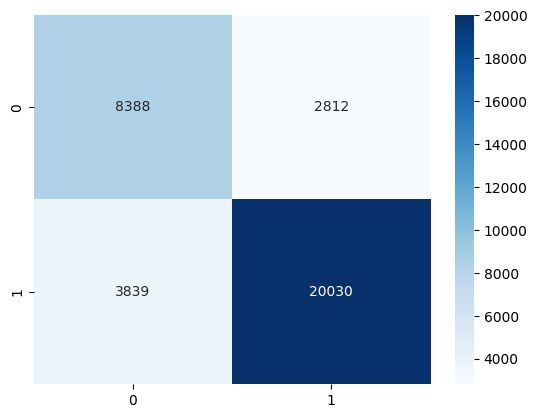

In [158]:
#evaluation

print(classification_report(y_test, preds))

print("ROC-AUC:", roc_auc_score(y_test, -scores))

cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()

### Final Model

In [159]:
final_iso = IsolationForest(
    n_estimators = best_params['n_estimators'],
    max_samples  = best_params['max_samples'],
    max_features = best_params['max_features'],
    contamination= best_params['contamination'],
    random_state=42,
    n_jobs=-1
)

final_iso.fit(X_train)   # X_train = all processed normal data

,n_estimators,200
,max_samples,0.7
,contamination,0.25
,max_features,0.6
,bootstrap,False
,n_jobs,-1
,random_state,42
,verbose,0
,warm_start,False


In [160]:
#predictions with final model
scores_final = final_iso.decision_function(X_test)
preds_final  = final_iso.predict(X_test)      
preds_binary = [1 if p == -1 else 0 for p in preds_final]

              precision    recall  f1-score   support

           0       0.69      0.75      0.72     11200
           1       0.88      0.84      0.86     23869

    accuracy                           0.81     35069
   macro avg       0.78      0.79      0.79     35069
weighted avg       0.82      0.81      0.81     35069

ROC-AUC: 0.8619930663203319


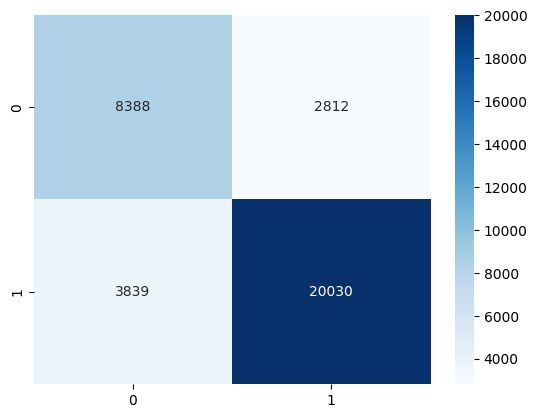

In [161]:
#evaluation of final model

print(classification_report(y_test, preds_binary))

print("ROC-AUC:", roc_auc_score(y_test, -scores_final))

cm_final = confusion_matrix(y_test, preds_binary)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues')
plt.show()

In [162]:
#saving
import joblib

joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']